In [1]:
import pandas as pd
import numpy as np

In [2]:
file_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\MS validation"

df = pd.read_csv(f"{file_path}/report.pg_matrix.tsv", sep="\t")

In [3]:
df_selected = df.iloc[:, [2] + list(range(6, df.shape[1]))]

In [4]:
import os

df_selected.columns = [os.path.basename(col).replace(".raw", "") for col in df_selected.columns]
df_selected

,Genes,A1,A2,A3,A4,A5,A6,A7,B1,B2,...,C5,C6,C7,D1,D2,D3,D4,D5,D6,D7
0,NUDT4B,775063.0,811549.0,773163.0,520218.0,620822.0,632274.0,464973.0,372285.0,582608.0,...,609435.0,475146.0,353757.0,861820.0,387637.0,489326.0,NaN,423769.0,612844.0,448005.0
1,SMIM26,987144.0,1033860.0,946989.0,1133960.0,NaN,1181220.0,1028110.0,1082280.0,1183620.0,...,1286150.0,1242930.0,1278170.0,302383.0,1058420.0,1321720.0,495338.0,952399.0,819127.0,1010200.0
2,PIGBOS1,2728590.0,1270910.0,1300230.0,1117340.0,NaN,1265840.0,1091120.0,1126510.0,1070070.0,...,1247310.0,1300010.0,1300490.0,NaN,2380380.0,1741270.0,NaN,953110.0,1337040.0,1247360.0
3,LBHD2,88018.4,124037.0,85837.8,67231.3,NaN,79457.4,98118.8,115641.0,111256.0,...,65838.6,NaN,100501.0,238669.0,157512.0,206567.0,NaN,161969.0,124974.0,187641.0
4,C20orf204,84252.7,70641.4,69711.8,77427.3,89732.4,59595.8,92686.5,108916.0,30446.4,...,75947.6,46159.4,60188.3,52344.2,47189.0,46765.7,NaN,34034.5,27395.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9126,FAM169A,28054000.0,28008600.0,26979600.0,28829400.0,27300500.0,28326200.0,28317700.0,29713900.0,28761600.0,...,29004400.0,30246300.0,33188500.0,26144000.0,30832300.0,31620300.0,20653200.0,30032400.0,31568100.0,31049000.0
9127,ZHX2,5817210.0,5779560.0,6078550.0,6259810.0,4255230.0,6606240.0,6549310.0,5670140.0,5599840.0,...,4443100.0,3968410.0,4477560.0,5270290.0,4638690.0,4733890.0,4148290.0,5195060.0,4463800.0,4529720.0
9128,MORC2,9273100.0,9391370.0,9367790.0,9606840.0,7242410.0,9308310.0,9634200.0,8955300.0,8916140.0,...,9112740.0,8532010.0,9191990.0,9743870.0,8745060.0,8981100.0,8919780.0,8985470.0,8523440.0,8740210.0
9129,IVNS1ABP,2755190.0,2675840.0,2475780.0,2424190.0,2347100.0,2272140.0,2257590.0,2740530.0,2674080.0,...,3301740.0,2946170.0,2960540.0,2207980.0,1646870.0,1776370.0,1722980.0,1673760.0,1607880.0,1755270.0


In [5]:
import re

def rename_sample(col):
    m = re.fullmatch(r'([ABCD])([1-7])', str(col))
    if not m:
        return col

    row, num = m.groups()

    mapping = {
        "A": "Control",
        "B": "VEH",
        "C": "Loratadine",
        "D": "MethyleneBlue"
    }

    return f"{mapping[row]}{num}"

df_selected.columns = [rename_sample(c) for c in df_selected.columns]

In [6]:
df_selected.set_index("Genes", inplace = True)
df_selected

,Control1,Control2,Control3,Control4,Control5,Control6,Control7,VEH1,VEH2,VEH3,...,Loratadine5,Loratadine6,Loratadine7,MethyleneBlue1,MethyleneBlue2,MethyleneBlue3,MethyleneBlue4,MethyleneBlue5,MethyleneBlue6,MethyleneBlue7
Genes,,,,,,,,,,,,,,,,,,,,,
NUDT4B,775063.0,811549.0,773163.0,520218.0,620822.0,632274.0,464973.0,372285.0,582608.0,547969.0,...,609435.0,475146.0,353757.0,861820.0,387637.0,489326.0,NaN,423769.0,612844.0,448005.0
SMIM26,987144.0,1033860.0,946989.0,1133960.0,NaN,1181220.0,1028110.0,1082280.0,1183620.0,1367110.0,...,1286150.0,1242930.0,1278170.0,302383.0,1058420.0,1321720.0,495338.0,952399.0,819127.0,1010200.0
PIGBOS1,2728590.0,1270910.0,1300230.0,1117340.0,NaN,1265840.0,1091120.0,1126510.0,1070070.0,2942070.0,...,1247310.0,1300010.0,1300490.0,NaN,2380380.0,1741270.0,NaN,953110.0,1337040.0,1247360.0
LBHD2,88018.4,124037.0,85837.8,67231.3,NaN,79457.4,98118.8,115641.0,111256.0,122934.0,...,65838.6,NaN,100501.0,238669.0,157512.0,206567.0,NaN,161969.0,124974.0,187641.0
C20orf204,84252.7,70641.4,69711.8,77427.3,89732.4,59595.8,92686.5,108916.0,30446.4,84270.9,...,75947.6,46159.4,60188.3,52344.2,47189.0,46765.7,NaN,34034.5,27395.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,28054000.0,28008600.0,26979600.0,28829400.0,27300500.0,28326200.0,28317700.0,29713900.0,28761600.0,26312600.0,...,29004400.0,30246300.0,33188500.0,26144000.0,30832300.0,31620300.0,20653200.0,30032400.0,31568100.0,31049000.0
ZHX2,5817210.0,5779560.0,6078550.0,6259810.0,4255230.0,6606240.0,6549310.0,5670140.0,5599840.0,5085780.0,...,4443100.0,3968410.0,4477560.0,5270290.0,4638690.0,4733890.0,4148290.0,5195060.0,4463800.0,4529720.0
MORC2,9273100.0,9391370.0,9367790.0,9606840.0,7242410.0,9308310.0,9634200.0,8955300.0,8916140.0,8903640.0,...,9112740.0,8532010.0,9191990.0,9743870.0,8745060.0,8981100.0,8919780.0,8985470.0,8523440.0,8740210.0


       group1         group2       p_value
0     Control            VEH  3.166039e-01
1     Control     Loratadine  3.495026e-09
2     Control  MethyleneBlue  7.662890e-06
3         VEH     Loratadine  1.534862e-08
4         VEH  MethyleneBlue  1.161150e-05
5  Loratadine  MethyleneBlue  2.041747e-09


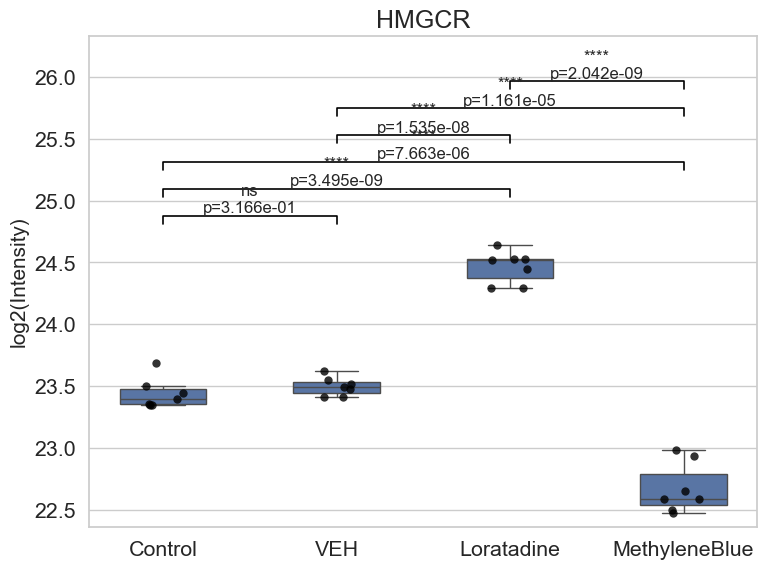

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind

# =========================
# 1. 提取 HMGCR 并做 log2
# =========================
gene = "HMGCR"

if gene not in df_selected.index:
    raise ValueError(f"{gene} not found in df_selected.index")

s = df_selected.loc[gene].copy()
s = pd.to_numeric(s, errors="coerce")
s_log2 = np.log2(s + 1)

plot_df = s_log2.reset_index()
plot_df.columns = ["sample", "value"]

def get_group(sample_name):
    sample_name = str(sample_name)
    if sample_name.startswith("Control"):
        return "Control"
    elif sample_name.startswith("VEH"):
        return "VEH"
    elif sample_name.startswith("Loratadine"):
        return "Loratadine"
    elif sample_name.startswith("MethyleneBlue"):
        return "MethyleneBlue"
    else:
        return None

plot_df["group"] = plot_df["sample"].apply(get_group)
plot_df = plot_df.dropna(subset=["group"]).copy()

group_order = ["Control", "VEH", "Loratadine", "MethyleneBlue"]
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

# =========================
# 2. 计算两两比较 P 值
# =========================
pair_results = []

for g1, g2 in combinations(group_order, 2):
    v1 = plot_df.loc[plot_df["group"] == g1, "value"].dropna()
    v2 = plot_df.loc[plot_df["group"] == g2, "value"].dropna()

    # Welch's t-test（更稳一些，不假设方差相等）
    stat, p = ttest_ind(v1, v2, equal_var=False)
    pair_results.append((g1, g2, p))

pair_df = pd.DataFrame(pair_results, columns=["group1", "group2", "p_value"])
print(pair_df)

# =========================
# 3. 画图
# =========================
sns.set(style="whitegrid", font_scale=1.4)

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=plot_df,
    x="group",
    y="value",
    order=group_order,
    width=0.5,
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="group",
    y="value",
    order=group_order,
    color="black",
    size=6,
    jitter=0.12,
    alpha=0.8,
    ax=ax
)

ax.set_title(f"{gene}", fontsize=18)
ax.set_xlabel("")
ax.set_ylabel("log2(Intensity)", fontsize=15)

# =========================
# 4. 添加显著性连线
# =========================
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=12)

y_max = plot_df["value"].max()
y_min = plot_df["value"].min()
y_range = y_max - y_min

start_y = y_max + 0.08 * y_range
step = 0.10 * y_range
h = 0.03 * y_range

group_to_x = {g: i for i, g in enumerate(group_order)}

for i, row in pair_df.iterrows():
    x1 = group_to_x[row["group1"]]
    x2 = group_to_x[row["group2"]]
    y = start_y + i * step
    stars = p_to_stars(row["p_value"])
    add_sig_bar(ax, x1, x2, y, h, f"{stars}\np={row['p_value']:.3e}")

ax.set_ylim(y_min - 0.05 * y_range, start_y + len(pair_df) * step + 0.1 * y_range)

plt.tight_layout()
plt.show()

       group1         group2       p_value
0     Control            VEH  3.166039e-01
1     Control     Loratadine  3.495026e-09
2     Control  MethyleneBlue  7.662890e-06
3         VEH     Loratadine  1.534862e-08
4         VEH  MethyleneBlue  1.161150e-05
5  Loratadine  MethyleneBlue  2.041747e-09

Pairwise comparison results:
       group1         group2       p_value significance
0     Control            VEH  3.166039e-01           ns
1     Control     Loratadine  3.495026e-09         ****
2     Control  MethyleneBlue  7.662890e-06         ****
3         VEH     Loratadine  1.534862e-08         ****
4         VEH  MethyleneBlue  1.161150e-05         ****
5  Loratadine  MethyleneBlue  2.041747e-09         ****


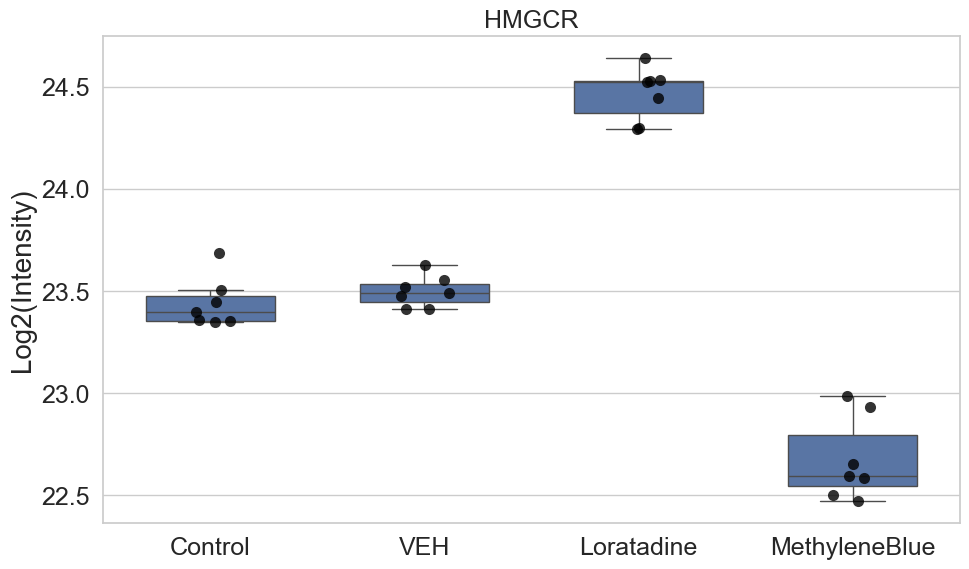

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind

# =========================
# 1. 提取 HMGCR 并做 log2
# =========================
gene = "HMGCR"
# gene = "HAMP"

if gene not in df_selected.index:
    raise ValueError(f"{gene} not found in df_selected.index")

s = df_selected.loc[gene].copy()
s = pd.to_numeric(s, errors="coerce")
s_log2 = np.log2(s + 1)

plot_df = s_log2.reset_index()
plot_df.columns = ["sample", "value"]

def get_group(sample_name):
    sample_name = str(sample_name)
    if sample_name.startswith("Control"):
        return "Control"
    elif sample_name.startswith("VEH"):
        return "VEH"
    elif sample_name.startswith("Loratadine"):
        return "Loratadine"
    elif sample_name.startswith("MethyleneBlue"):
        return "MethyleneBlue"
    else:
        return None

plot_df["group"] = plot_df["sample"].apply(get_group)
plot_df = plot_df.dropna(subset=["group"]).copy()

group_order = ["Control", "VEH", "Loratadine", "MethyleneBlue"]
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

# =========================
# 2. 计算两两比较 P 值
# =========================
pair_results = []

for g1, g2 in combinations(group_order, 2):
    v1 = plot_df.loc[plot_df["group"] == g1, "value"].dropna()
    v2 = plot_df.loc[plot_df["group"] == g2, "value"].dropna()

    # Welch's t-test
    stat, p = ttest_ind(v1, v2, equal_var=False)

    pair_results.append({
        "group1": g1,
        "group2": g2,
        "p_value": p
    })

pair_df = pd.DataFrame(pair_results)

print(pair_df)

# 如果你想顺便加一个显著性标记列
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

pair_df["significance"] = pair_df["p_value"].apply(p_to_stars)

print("\nPairwise comparison results:")
print(pair_df)

# =========================
# 3. 画图：boxplot + data points
# =========================
sns.set(style="whitegrid", font_scale=1.4)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="group",
    y="value",
    order=group_order,
    width=0.6,
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="group",
    y="value",
    order=group_order,
    color="black",
    size=8,
    jitter=0.12,
    alpha=0.8,
    ax=ax
)

ax.set_title(gene, fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.set_xlabel("")
ax.set_ylabel("Log2(Intensity)", fontsize=20)

plt.tight_layout()
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\figures"
plt.savefig(f"{figure_path}/MS_validation_MB.svg", dpi=600, bbox_inches="tight")
plt.show()